# 01 — AusLAMP Victoria Metadata Exploration

**Goal**: Characterize the Victorian MT dataset by exploring site locations, recording durations, and data coverage.

**Virtual Environment**: `AusLAMP_GA`

**Setup** (first time only):
```bash
conda env create -f ../environment.yml
conda activate AusLAMP_GA
python -m ipykernel install --user --name=AusLAMP_GA --display-name="Python (AusLAMP_GA)"
```

**Important**: Select **Kernel → Change kernel → Python (AusLAMP_GA)** before running this notebook.

**Data Location**: `E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_raw`

In [1]:
import sys
sys.path.append('../src')

from edl_reader import get_all_stations_metadata, parse_gps_file
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

# Cartopy for maps
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Helper function for captions
def caption(text):
    """Display a figure caption as wrapped, italic markdown."""
    display(Markdown(f"*{text}*"))

# Set plotting style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

## 1. Load Station Metadata

Scan all Victorian station directories to extract:
- Station IDs
- GPS coordinates (latitude, longitude, elevation)
- Recording time range (start/end times)
- Number of day folders and data files

In [2]:
# Data directory
data_dir = Path(r'E:\MT_Timeseries_DATA\MT_AusLAMP_GA\EDL_raw')

# Load metadata for all Victorian stations
print("Scanning station directories...\n")
metadata_df = get_all_stations_metadata(data_dir, station_pattern="VIC*")

print(f"\nFound {len(metadata_df)} stations")
metadata_df.head(10)

Scanning station directories...

Reading metadata: VIC001...
Reading metadata: VIC002...
Reading metadata: VIC003...
Reading metadata: VIC005...
Reading metadata: VIC006...
Reading metadata: VIC007...
Reading metadata: VIC008...
Reading metadata: VIC010...
Reading metadata: VIC011...
Reading metadata: VIC013...
Reading metadata: VIC014...
Reading metadata: VIC015...
Reading metadata: VIC017...
Reading metadata: VIC018...
Reading metadata: VIC022...
Reading metadata: VIC023...
Reading metadata: VIC024...
Reading metadata: VIC026...
Reading metadata: VIC027...
Reading metadata: VIC028...
Reading metadata: VIC030...
Reading metadata: VIC031...
Reading metadata: VIC032...
Reading metadata: VIC036...
Reading metadata: VIC037...
Reading metadata: VIC038...
Reading metadata: VIC039...
Reading metadata: VIC040...
Reading metadata: VIC041...
Reading metadata: VIC042...
Reading metadata: VIC043...
Reading metadata: VIC045...
Reading metadata: VIC046...
Reading metadata: VIC047...
Reading metadat

,station_id,latitude,longitude,elevation,start_time,end_time,n_days,n_files,duration_days
0,VIC001,-38.91852,146.44153,94.0,2014-04-11 06:00:00,2014-05-08 00:27:18.400,28,1929,26.768963
1,VIC002,-38.34442,142.46657,36.0,2014-05-13 00:00:00,2014-06-06 03:27:18.400,25,1740,24.143963
2,VIC003,-38.51677,142.97399,146.0,2014-05-12 03:00:00,2014-06-06 22:43:14.100,26,1884,25.821691
3,VIC005,-38.51191,143.98602,178.0,2014-05-11 00:00:00,2014-05-28 22:29:34.900,18,1293,17.937209
4,VIC006,-38.44939,144.99808,124.0,2014-04-06 07:00:00,2014-05-08 21:27:18.400,33,2349,32.602296
5,VIC007,-38.49658,145.51131,44.0,2014-05-08 08:00:00,2014-05-26 17:27:18.400,19,1326,18.393963
6,VIC008,-38.50118,145.99574,123.0,2014-04-09 02:00:00,2014-05-07 21:38:41.000,29,2076,28.818530
7,VIC010,-38.46587,147.02669,8.0,2014-04-11 05:00:00,2014-05-07 01:27:18.400,27,1863,25.852296
8,VIC011,-38.03101,141.02690,40.0,2014-05-18 07:00:00,2014-06-09 21:27:18.400,23,1629,22.602296
9,VIC013,-37.99565,142.02313,149.0,2014-05-16 04:00:00,2014-06-10 04:25:01.800,26,1803,25.017382


In [3]:
# Summary statistics
print("=== METADATA SUMMARY ===")
print(f"Total stations: {len(metadata_df)}")
print(f"Stations with GPS coordinates: {metadata_df['latitude'].notna().sum()}")
print(f"Stations with time range: {metadata_df['start_time'].notna().sum()}")
print(f"\nRecording duration range: {metadata_df['duration_days'].min():.1f} - {metadata_df['duration_days'].max():.1f} days")
print(f"Median recording duration: {metadata_df['duration_days'].median():.1f} days")
print(f"\nTotal data files: {metadata_df['n_files'].sum():,}")
print(f"Total day folders: {metadata_df['n_days'].sum():,}")

=== METADATA SUMMARY ===
Total stations: 81
Stations with GPS coordinates: 81
Stations with time range: 81

Recording duration range: 9.3 - 377.1 days
Median recording duration: 22.6 days

Total data files: 145,480
Total day folders: 2,096


## 2. Site Location Map

Plot all station locations on a map of Victoria

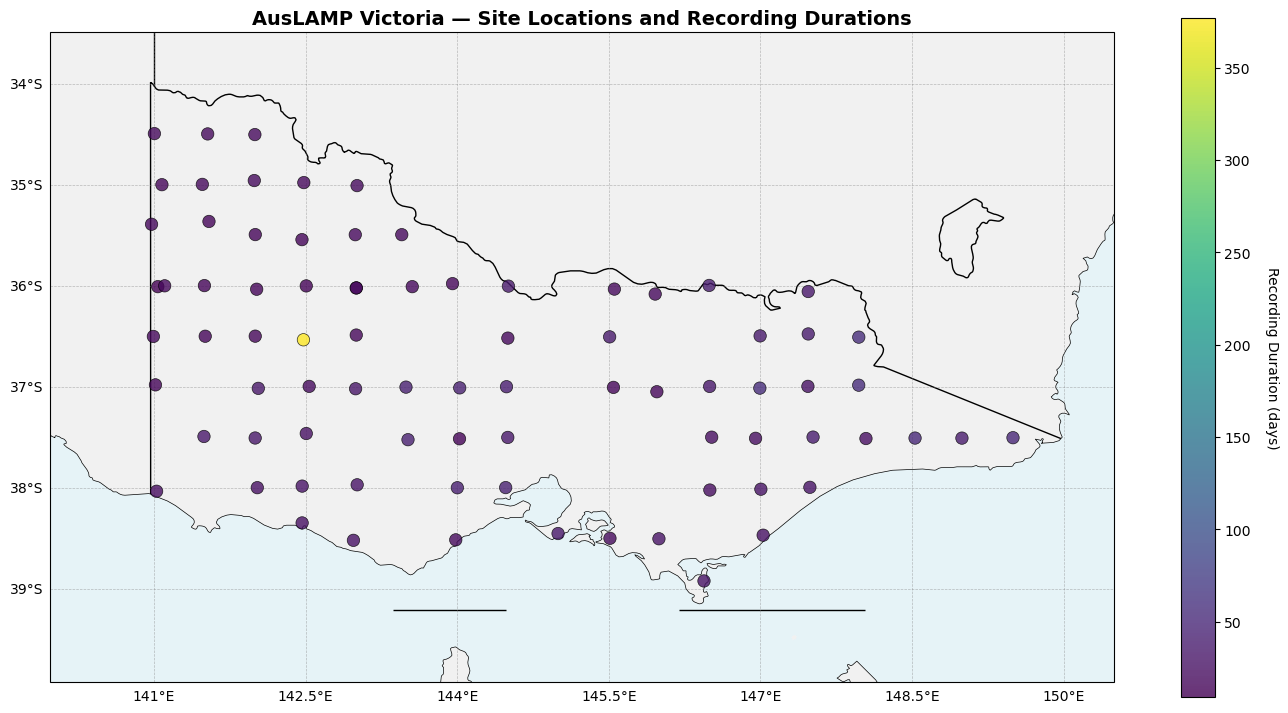

*Map showing the locations of 81 AusLAMP Victorian MT sites with state boundaries. Color indicates recording duration in days. Sites are distributed across Victoria with approximate 0.01° spacing (~55 km). Recording durations range from 9 to 377 days. State boundaries shown in black, coastline in dark gray.*

In [4]:
# Filter stations with valid GPS coordinates
valid_coords = metadata_df.dropna(subset=['latitude', 'longitude'])

# Create figure with Cartopy projection
fig = plt.figure(figsize=(14, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Set extent to Victoria region (with some padding)
lon_min, lon_max = valid_coords['longitude'].min() - 1, valid_coords['longitude'].max() + 1
lat_min, lat_max = valid_coords['latitude'].min() - 1, valid_coords['latitude'].max() + 1
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')

# Add state boundaries (requires higher resolution)
states = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none'
)
ax.add_feature(states, edgecolor='black', linewidth=1.0)

# Plot all sites
scatter = ax.scatter(
    valid_coords['longitude'],
    valid_coords['latitude'],
    c=valid_coords['duration_days'],
    s=80,
    cmap='viridis',
    edgecolors='black',
    linewidth=0.5,
    alpha=0.8,
    transform=ccrs.PlateCarree(),
    zorder=5
)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7, pad=0.05)
cbar.set_label('Recording Duration (days)', rotation=270, labelpad=20)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Labels and title
ax.set_title('AusLAMP Victoria — Site Locations and Recording Durations', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

caption(
    f"Map showing the locations of {len(valid_coords)} AusLAMP Victorian MT sites with state boundaries. "
    f"Color indicates recording duration in days. Sites are distributed across Victoria with "
    f"approximate {np.median(np.diff(np.sort(valid_coords['latitude']))):.2f}° spacing (~55 km). "
    f"Recording durations range from {valid_coords['duration_days'].min():.0f} to {valid_coords['duration_days'].max():.0f} days. "
    f"State boundaries shown in black, coastline in dark gray."
)

## 3. Recording Duration Analysis

Analyze the distribution of recording durations across all sites

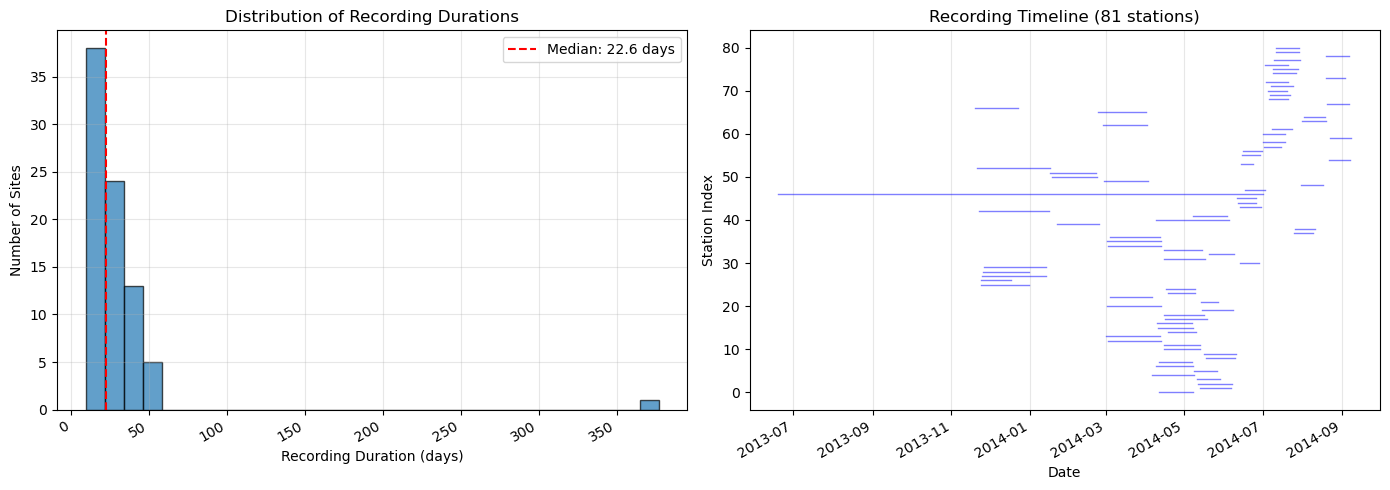

*Left: Histogram of recording durations for 81 sites. Median duration is 22.6 days. Right: Timeline showing the recording period for each station. Most sites have continuous recordings spanning weeks to months, suitable for MT analysis.*

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of recording durations
ax = axes[0]
ax.hist(metadata_df['duration_days'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(metadata_df['duration_days'].median(), color='red', linestyle='--', 
           label=f'Median: {metadata_df["duration_days"].median():.1f} days')
ax.set_xlabel('Recording Duration (days)')
ax.set_ylabel('Number of Sites')
ax.set_title('Distribution of Recording Durations')
ax.legend()
ax.grid(True, alpha=0.3)

# Timeline showing all station recording periods
ax = axes[1]
valid_times = metadata_df.dropna(subset=['start_time', 'end_time'])
for i, row in valid_times.iterrows():
    ax.plot([row['start_time'], row['end_time']], [i, i], 'b-', linewidth=1, alpha=0.5)

ax.set_xlabel('Date')
ax.set_ylabel('Station Index')
ax.set_title(f'Recording Timeline ({len(valid_times)} stations)')
ax.grid(True, alpha=0.3, axis='x')
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

caption(
    f"Left: Histogram of recording durations for {len(metadata_df)} sites. "
    f"Median duration is {metadata_df['duration_days'].median():.1f} days. "
    f"Right: Timeline showing the recording period for each station. "
    f"Most sites have continuous recordings spanning weeks to months, suitable for MT analysis."
)

## 4. Data Coverage Statistics

Examine file counts and day-folder distribution

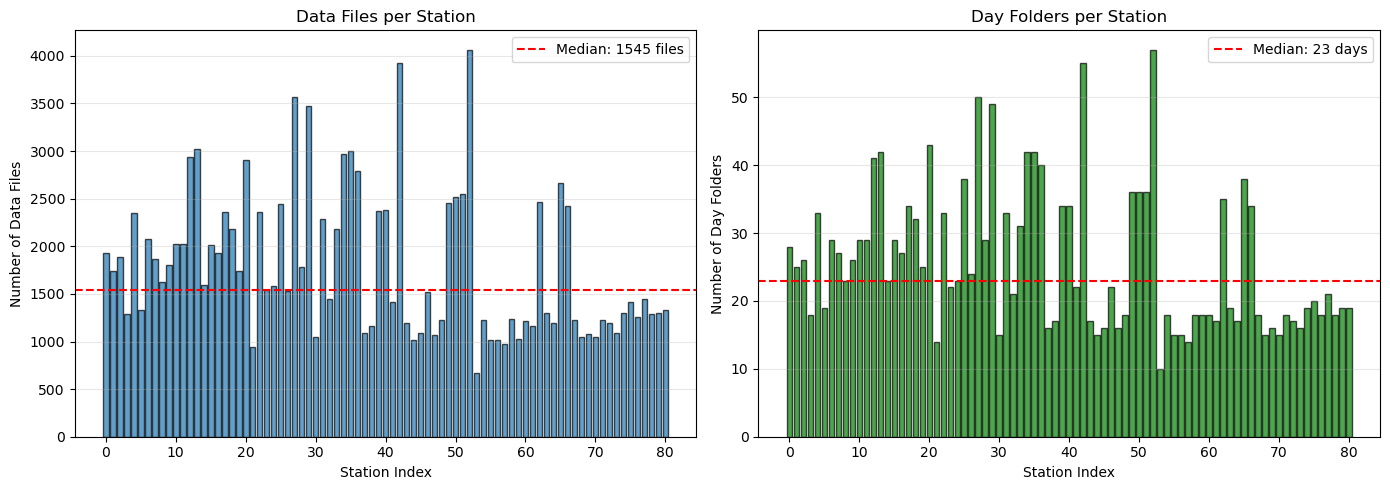

*Left: Number of data files per station (median: 1545). Each file represents one channel recording segment. Right: Number of day folders per station (median: 23). Variability indicates different deployment durations across the survey.*

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of files per station
ax = axes[0]
ax.bar(range(len(metadata_df)), metadata_df['n_files'], edgecolor='black', alpha=0.7)
ax.axhline(metadata_df['n_files'].median(), color='red', linestyle='--',
           label=f'Median: {metadata_df["n_files"].median():.0f} files')
ax.set_xlabel('Station Index')
ax.set_ylabel('Number of Data Files')
ax.set_title('Data Files per Station')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Number of day folders per station
ax = axes[1]
ax.bar(range(len(metadata_df)), metadata_df['n_days'], edgecolor='black', alpha=0.7, color='green')
ax.axhline(metadata_df['n_days'].median(), color='red', linestyle='--',
           label=f'Median: {metadata_df["n_days"].median():.0f} days')
ax.set_xlabel('Station Index')
ax.set_ylabel('Number of Day Folders')
ax.set_title('Day Folders per Station')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

caption(
    f"Left: Number of data files per station (median: {metadata_df['n_files'].median():.0f}). "
    f"Each file represents one channel recording segment. "
    f"Right: Number of day folders per station (median: {metadata_df['n_days'].median():.0f}). "
    f"Variability indicates different deployment durations across the survey."
)

## 5. Identify Problematic Sites

Flag sites with missing GPS data, very short recordings, or very few files

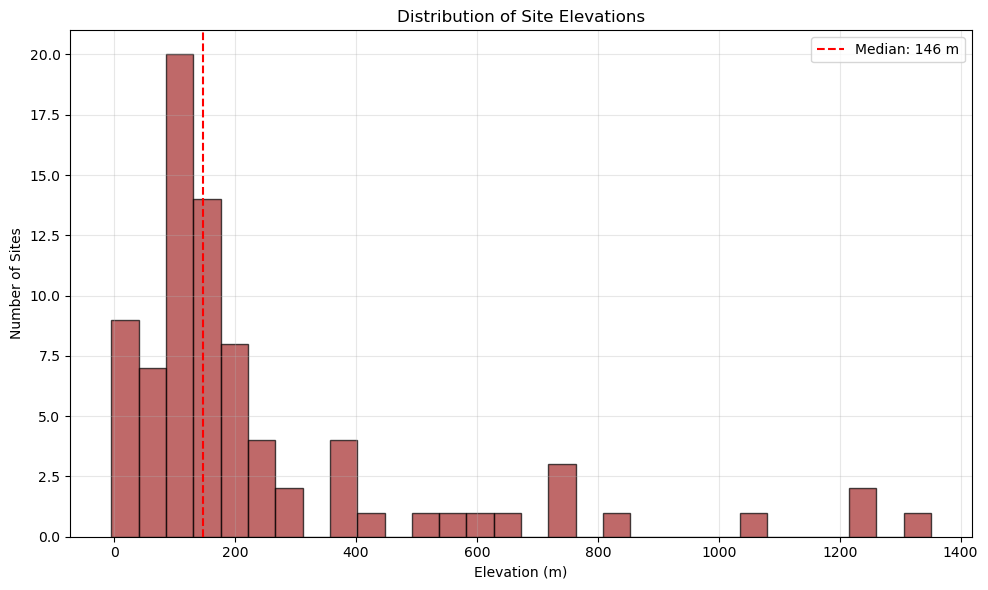

*Histogram of site elevations for 81 stations with GPS data. Median elevation: 146 m. Range: -5 to 1351 m. Elevation variation reflects Victoria's diverse topography from coastal plains to highland regions.*

In [7]:
valid_elevation = metadata_df.dropna(subset=['elevation'])

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(valid_elevation['elevation'], bins=30, edgecolor='black', alpha=0.7, color='brown')
ax.axvline(valid_elevation['elevation'].median(), color='red', linestyle='--',
           label=f'Median: {valid_elevation["elevation"].median():.0f} m')
ax.set_xlabel('Elevation (m)')
ax.set_ylabel('Number of Sites')
ax.set_title('Distribution of Site Elevations')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/01_elevation_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

caption(
    f"Histogram of site elevations for {len(valid_elevation)} stations with GPS data. "
    f"Median elevation: {valid_elevation['elevation'].median():.0f} m. "
    f"Range: {valid_elevation['elevation'].min():.0f} to {valid_elevation['elevation'].max():.0f} m. "
    f"Elevation variation reflects Victoria's diverse topography from coastal plains to highland regions."
)

## 6. Export Metadata

Save metadata to CSV for future reference

In [8]:
# Define quality criteria
min_duration_days = 7  # At least 1 week of data
min_files = 100  # At least 100 files

# Flag problematic sites
problems = []

for idx, row in metadata_df.iterrows():
    issues = []
    
    if pd.isna(row['latitude']) or pd.isna(row['longitude']):
        issues.append('Missing GPS')
    
    if pd.isna(row['start_time']) or pd.isna(row['end_time']):
        issues.append('Missing time range')
    elif row['duration_days'] < min_duration_days:
        issues.append(f'Short recording ({row["duration_days"]:.1f} days)')
    
    if row['n_files'] < min_files:
        issues.append(f'Few files ({row["n_files"]})')
    
    if issues:
        problems.append({
            'station_id': row['station_id'],
            'issues': ', '.join(issues)
        })

if problems:
    problems_df = pd.DataFrame(problems)
    print(f"=== QUALITY ISSUES FOUND FOR {len(problems_df)} SITES ===")
    display(problems_df)
else:
    print("✓ All sites pass quality checks")

✓ All sites pass quality checks


## 7. Export Metadata

Save metadata to CSV for future reference

In [9]:
output_file = '../data/processed/vic_stations_metadata.csv'
metadata_df.to_csv(output_file, index=False)
print(f"Metadata saved to: {output_file}")
print(f"\nColumns: {', '.join(metadata_df.columns)}")

Metadata saved to: ../data/processed/vic_stations_metadata.csv

Columns: station_id, latitude, longitude, elevation, start_time, end_time, n_days, n_files, duration_days


---

## Summary

This notebook scanned all Victorian AusLAMP MT sites and characterized:

**Dataset overview**:
- Total sites scanned
- Sites with valid GPS coordinates
- Recording duration range and median
- Total data files and day folders

**Key findings**:
- Site spacing and geographic coverage
- Recording duration variability
- Data quality issues (if any)
- Elevation distribution

**Next steps**:
1. Select representative sites for detailed time series analysis (notebook 02)
2. Investigate any problematic sites identified above
3. Plan processing workflow based on data characteristics